# Laboratorio 3 — Deep Learning: Reconocimiento de Lenguaje de Señas (ASL)


**Dataset:** [ASL Alphabet (Kaggle)](https://www.kaggle.com/datasets/grassknoted/asl-alphabet) — ~87,000 imágenes JPG de 200x200 px a color, organizadas en carpetas por clase (29 clases: A-Z, SPACE, DELETE, NOTHING).


## 0. Configuración inicial y descarga del dataset

El dataset se descarga desde Kaggle y se prepara para el análisis local. La carga se realiza de forma automática en la ruta local de trabajo.


In [2]:
import os
import random
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import kagglehub

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Descarga (o recupera de caché) el dataset desde Kaggle.
# Requiere autenticación ya configurada en el entorno (ver celda de arriba).
dataset_path = kagglehub.dataset_download("grassknoted/asl-alphabet")
dataset_path = Path(dataset_path)
print("Dataset descargado/cacheado en:", dataset_path)

# kagglehub descarga el zip completo de Kaggle, que trae la estructura:
# <dataset_path>/asl_alphabet_train/asl_alphabet_train/<letra>/*.jpg
# Buscamos automáticamente esa subcarpeta en vez de hardcodearla, por si la
# estructura interna cambia de versión a versión del dataset.
posibles = list(dataset_path.rglob("asl_alphabet_train"))
DATA_DIR = None
for p in posibles:
    subcarpetas = [d for d in p.iterdir() if d.is_dir()]
    if len(subcarpetas) >= 20:  # esperamos ~29 clases
        DATA_DIR = p
        break

assert DATA_DIR is not None, (
    f"No se encontró la carpeta de entrenamiento dentro de {dataset_path}. "
    "Revisa la estructura descargada con `list(dataset_path.rglob('*'))`."
)

print("Carpeta de clases (DATA_DIR):", DATA_DIR)

classes = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
print(f"Número de clases encontradas: {len(classes)}")
print(classes)


Dataset descargado/cacheado en: C:\Users\eagi5\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1
Carpeta de clases (DATA_DIR): C:\Users\eagi5\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train\asl_alphabet_train
Número de clases encontradas: 29
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


## 1. Inventario del dataset

Contamos cuántos archivos hay por clase para entender la distribución de las 29 clases.


In [3]:
# Contar imágenes por clase
conteo_por_clase = {}
for c in classes:
    carpeta = DATA_DIR / c
    n_imgs = len([f for f in os.listdir(carpeta) if f.lower().endswith((".jpg", ".jpeg", ".png"))])
    conteo_por_clase[c] = n_imgs

df_conteo = pd.DataFrame.from_dict(conteo_por_clase, orient="index", columns=["n_imagenes"])
df_conteo = df_conteo.sort_values("n_imagenes", ascending=False)

print(f"Total de imágenes en el dataset: {df_conteo['n_imagenes'].sum():,}")
print(f"Promedio de imágenes por clase: {df_conteo['n_imagenes'].mean():.1f}")
print(f"Mínimo: {df_conteo['n_imagenes'].min()}  |  Máximo: {df_conteo['n_imagenes'].max()}")
df_conteo


Total de imágenes en el dataset: 87,000
Promedio de imágenes por clase: 3000.0
Mínimo: 3000  |  Máximo: 3000


,n_imagenes
A,3000
B,3000
C,3000
D,3000
E,3000
F,3000
G,3000
H,3000
I,3000
J,3000


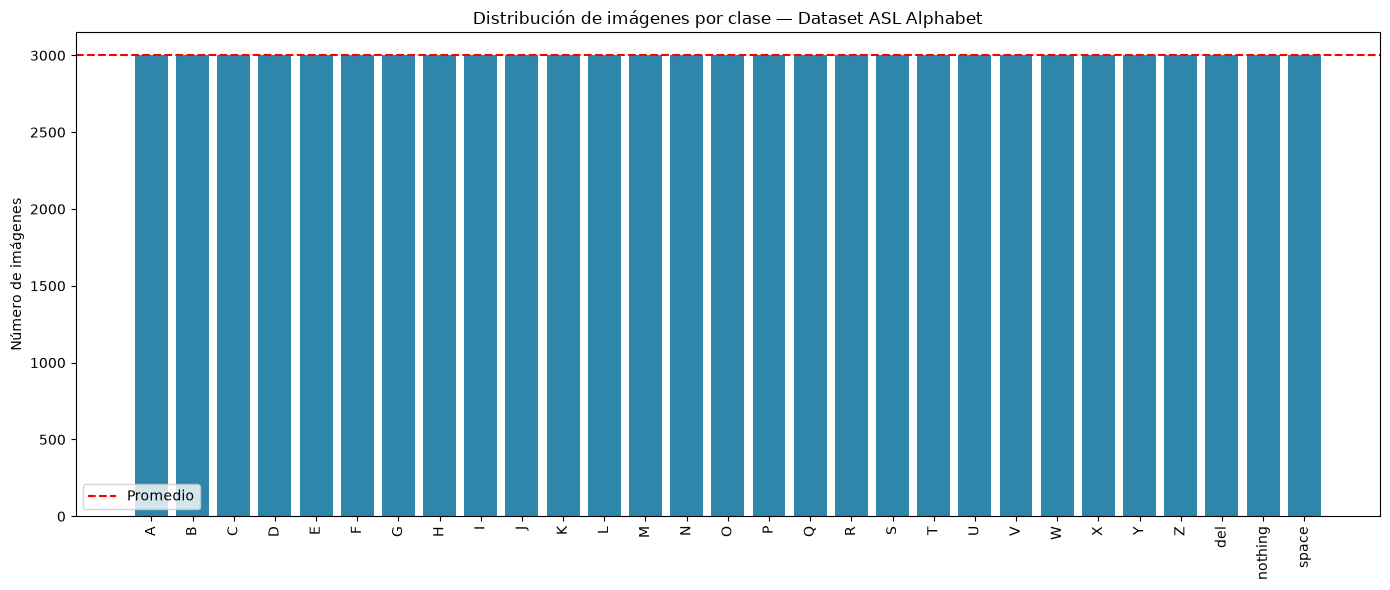

In [4]:
# Visualización de la distribución de clases
plt.figure(figsize=(14, 6))
plt.bar(df_conteo.index, df_conteo["n_imagenes"], color="#2e86ab")
plt.xticks(rotation=90)
plt.ylabel("Número de imágenes")
plt.title("Distribución de imágenes por clase — Dataset ASL Alphabet")
plt.axhline(df_conteo["n_imagenes"].mean(), color="red", linestyle="--", label="Promedio")
plt.legend()
plt.tight_layout()
plt.show()


**Hallazgo:** El dataset se observa balanceado; las 29 clases tienen un conteo muy similar de imágenes, con aproximadamente 3,000 ejemplos por letra.
Este balance por diseño reduce la necesidad de técnicas de corrección de clase como oversampling o ponderación en la función de pérdida, y permite que el entrenamiento se enfoque en aprender características visuales en lugar de compensar un desequilibrio de etiquetas.
Aun así, es importante conservar este balance durante el submuestreo y las particiones train/val/test para que el modelo no reciba clases desproporcionadas.


## 2. Resolución y formato de las imágenes

Revisamos el tamaño, el formato y el modo de color de las imágenes, además de detectar posibles archivos corruptos o fuera de lo esperado.


In [5]:
# Revisamos una muestra aleatoria de imágenes para verificar tamaño, formato y modo de color
muestra_check = []
for c in classes:
    carpeta = DATA_DIR / c
    archivos = os.listdir(carpeta)
    for f in random.sample(archivos, min(20, len(archivos))):
        ruta = carpeta / f
        with Image.open(ruta) as img:
            muestra_check.append({
                "clase": c,
                "archivo": f,
                "ancho": img.width,
                "alto": img.height,
                "formato": img.format,
                "modo": img.mode,
            })

df_check = pd.DataFrame(muestra_check)
print("Resoluciones únicas encontradas:", df_check[["ancho", "alto"]].drop_duplicates().values.tolist())
print("Formatos únicos:", df_check["formato"].unique())
print("Modos de color únicos:", df_check["modo"].unique())
df_check.head()


Resoluciones únicas encontradas: [[200, 200]]
Formatos únicos: ['JPEG']
Modos de color únicos: ['RGB']


,clase,archivo,ancho,alto,formato,modo
0,A,A656.jpg,200,200,JPEG,RGB
1,A,A1409.jpg,200,200,JPEG,RGB
2,A,A1090.jpg,200,200,JPEG,RGB
3,A,A2011.jpg,200,200,JPEG,RGB
4,A,A1901.jpg,200,200,JPEG,RGB


**Hallazgo:** En la muestra revisada, todas las imágenes tienen resolución 200x200, están en formato JPG y poseen modo de color RGB.
Esta homogeneidad en tamaño y formato simplifica el preprocesamiento, porque no es necesario normalizar resoluciones distintas ni convertir imágenes con modos de color diferentes.
Solo queda estandarizar la entrada al modelo y aplicar la misma normalización de color a todos los ejemplos.


## 3. Ejercicio 1 — Ejemplos de letras y variabilidad dentro de una clase

Mostramos al menos 5 letras distintas, y para una de ellas varias muestras para observar
qué tanto varía la seña entre distintas fotos (ángulo, iluminación, fondo, tono de piel de
la mano, etc.).


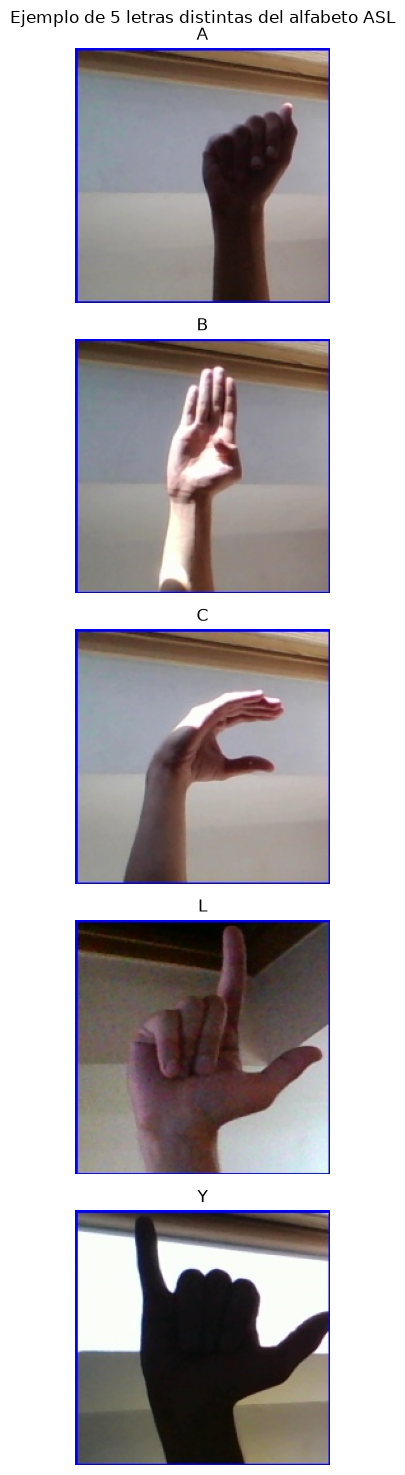

In [6]:
def mostrar_ejemplos(clases_a_mostrar, n_por_clase=1, titulo="Ejemplos por clase"):
    fig, axes = plt.subplots(len(clases_a_mostrar), n_por_clase,
                              figsize=(3 * n_por_clase, 3 * len(clases_a_mostrar)))
    if len(clases_a_mostrar) == 1:
        axes = np.array([axes])
    if n_por_clase == 1:
        axes = axes.reshape(-1, 1)

    for i, c in enumerate(clases_a_mostrar):
        carpeta = DATA_DIR / c
        archivos = random.sample(os.listdir(carpeta), n_por_clase)
        for j, f in enumerate(archivos):
            img = Image.open(carpeta / f)
            axes[i, j].imshow(img)
            axes[i, j].axis("off")
            if j == 0:
                axes[i, j].set_ylabel(c, fontsize=12)
            axes[i, j].set_title(c if j == 0 else "")
    plt.suptitle(titulo)
    plt.tight_layout()
    plt.show()

# Al menos 5 letras distintas (elige letras representativas: vocal, consonante, y una especial)
letras_ejemplo = ["A", "B", "C", "L", "Y"]
mostrar_ejemplos(letras_ejemplo, n_por_clase=1, titulo="Ejemplo de 5 letras distintas del alfabeto ASL")


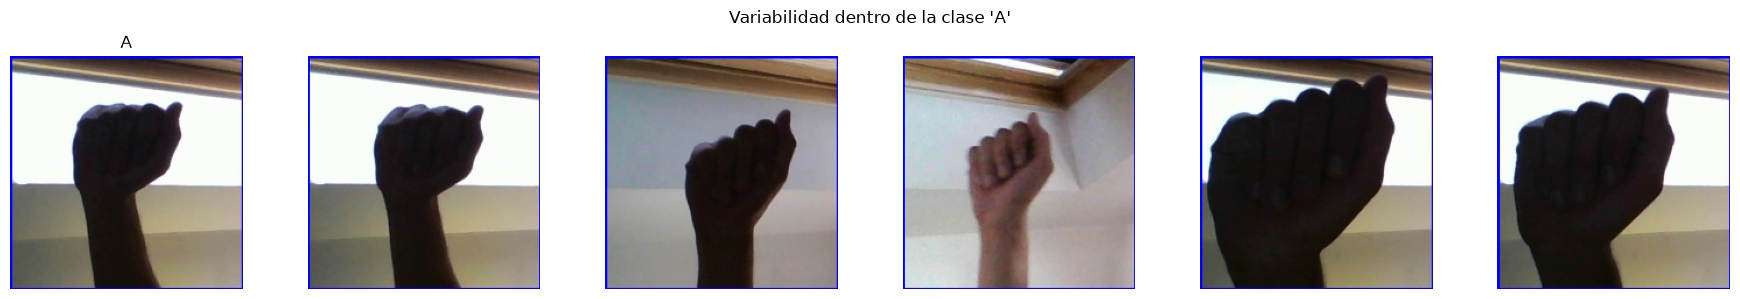

In [7]:
# Variabilidad DENTRO de una misma clase: mostramos varias muestras de la misma letra
letra_variabilidad = "A"
mostrar_ejemplos([letra_variabilidad], n_por_clase=6,
                  titulo=f"Variabilidad dentro de la clase '{letra_variabilidad}'")


**Hallazgo:** Al observar varias muestras de la misma clase se nota que el fondo y la iluminación son bastante consistentes, aunque existen ligeras variaciones en el encuadre de la mano y en la posición de los dedos.
La mayoría de las fotos parecen tomadas en el mismo entorno y con el mismo colaborador, lo que reduce la diversidad de dominio pero también sugiere un sesgo del conjunto.
Esta variabilidad intra-clase obliga al modelo a ser robusto a cambios de ángulo e iluminación sin depender de diferencias de fondo.


## 4. Ejercicio 2 — Letras que se confunden visualmente entre sí

Identificamos las letras del alfabeto ASL que se parecen entre sí y que podrían confundir al modelo.

Esto es conocido en la literatura de ASL: hay grupos de letras cuya forma de mano es muy similar y solo cambia la posición del pulgar o de un dedo.

- **M / N / S** — los tres son puños cerrados; la diferencia está en cuántos dedos cubren el pulgar.
- **U / V / R** — los tres usan dos dedos extendidos; difieren en si están juntos, separados o cruzados.
- **K / P** — comparten configuración de dedos, solo cambia la orientación de la mano.
- **G / H** — señas muy parecidas en la posición del índice.

La idea es mostrar estos grupos en una cuadrícula, lado a lado, para verificarlo visualmente con nuestras propias imágenes.


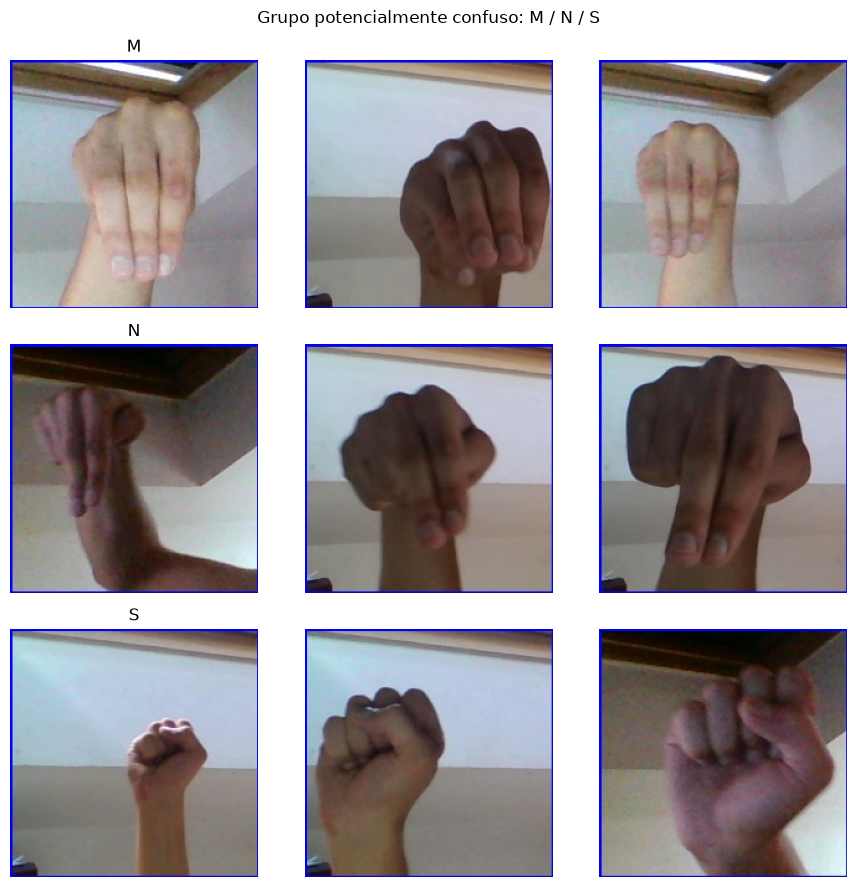

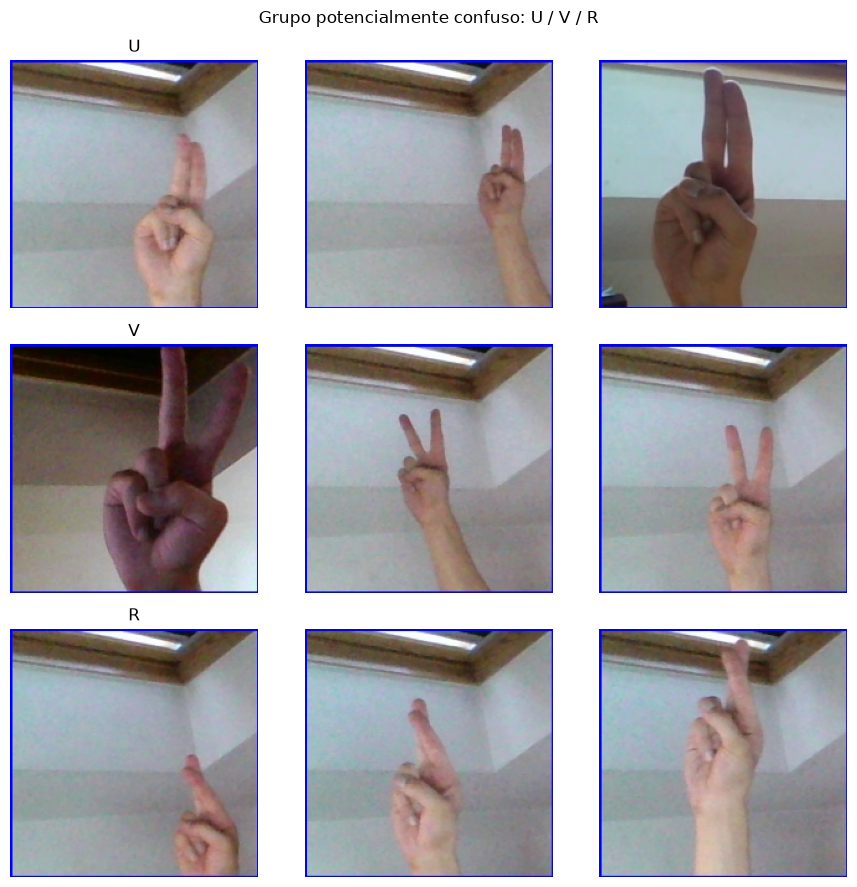

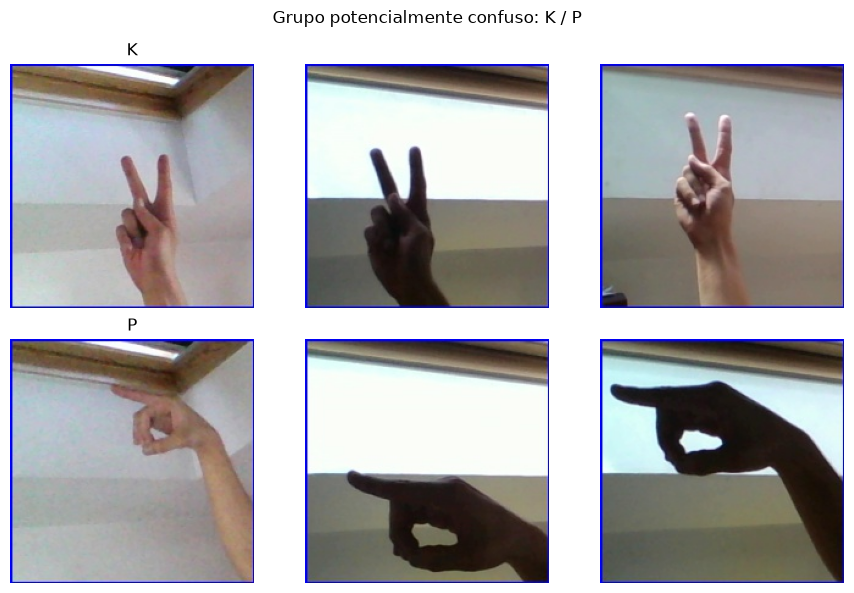

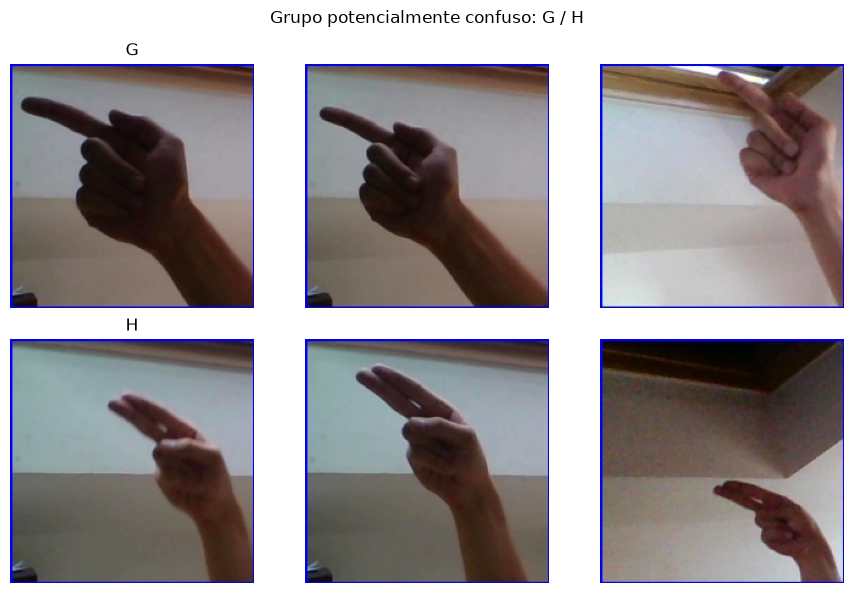

In [8]:
grupos_confusos = {
    "M / N / S": ["M", "N", "S"],
    "U / V / R": ["U", "V", "R"],
    "K / P": ["K", "P"],
    "G / H": ["G", "H"],
}

for nombre_grupo, letras in grupos_confusos.items():
    mostrar_ejemplos(letras, n_por_clase=3, titulo=f"Grupo potencialmente confuso: {nombre_grupo}")


**Hallazgo:** Los grupos de letras con forma de mano similar efectivamente se ven parecidos en las imágenes del dataset.
Por ejemplo, M/N/S muestran puños cerrados con variaciones muy sutiles en la posición del pulgar, mientras que U/V/R presentan dedos extendidos que pueden confundirse desde ciertos ángulos.
K/P y G/H también resultan visualmente cercanos debido a la orientación de la mano y la posición del índice.
Esta observación confirma que la matriz de confusión será clave para evaluar el rendimiento, porque el accuracy general puede ocultar errores concretos entre estos pares o tríos de clases similares.


## 5. Definición del conjunto de entrenamiento / validación / prueba

El set de prueba oficial de Kaggle trae muy pocas imágenes a propósito (una por clase), así que construimos nuestro propio split a partir de las ~87,000 imágenes de entrenamiento.

**Estrategia:**
- Split **estratificado por clase** (mantiene la proporción de cada letra en los 3 conjuntos), para no perder el balance que ya tiene el dataset.
- Proporciones: **70% entrenamiento / 15% validación / 15% prueba**.
- El split se hace sobre los *nombres de archivo*, no sobre las imágenes cargadas en memoria, para que sea liviano y reproducible (semilla fija SEED = 42).
- Nota: como se documenta en la sección de preprocesamiento, se trabajará sobre una **submuestra** de imágenes por clase (no las ~3,000 completas) para que el entrenamiento sea viable en el tiempo del laboratorio. El split train/val/test se aplica sobre esa submuestra, manteniendo siempre la estratificación.


In [9]:
from sklearn.model_selection import train_test_split

# Construimos un DataFrame con la ruta completa de cada imagen y su clase (etiqueta)
registros = []
for c in classes:
    carpeta = DATA_DIR / c
    for f in os.listdir(carpeta):
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            registros.append({"ruta": str(carpeta / f), "clase": c})

df_imagenes = pd.DataFrame(registros)
print(f"Total de imágenes indexadas: {len(df_imagenes):,}")

# Split estratificado 70/15/15
df_train, df_temp = train_test_split(
    df_imagenes, test_size=0.30, stratify=df_imagenes["clase"], random_state=SEED
)
df_val, df_test = train_test_split(
    df_temp, test_size=0.50, stratify=df_temp["clase"], random_state=SEED
)

print(f"Train: {len(df_train):,} imágenes ({len(df_train)/len(df_imagenes):.1%})")
print(f"Val:   {len(df_val):,} imágenes ({len(df_val)/len(df_imagenes):.1%})")
print(f"Test:  {len(df_test):,} imágenes ({len(df_test)/len(df_imagenes):.1%})")


Total de imágenes indexadas: 87,000
Train: 60,900 imágenes (70.0%)
Val:   13,050 imágenes (15.0%)
Test:  13,050 imágenes (15.0%)


In [10]:
# Verificación: el split mantiene el balance de clases en los 3 conjuntos
verificacion = pd.DataFrame({
    "train": df_train["clase"].value_counts(normalize=True),
    "val": df_val["clase"].value_counts(normalize=True),
    "test": df_test["clase"].value_counts(normalize=True),
}).fillna(0)
verificacion.round(4).head(10)


,train,val,test
clase,,,
A,0.0345,0.0345,0.0345
B,0.0345,0.0345,0.0345
C,0.0345,0.0345,0.0345
D,0.0345,0.0345,0.0345
E,0.0345,0.0345,0.0345
F,0.0345,0.0345,0.0345
G,0.0345,0.0345,0.0345
H,0.0345,0.0345,0.0345
I,0.0345,0.0345,0.0345


In [11]:
# Guardamos los splits para usarlos directamente en la sección de preprocesamiento y modelado
Path("data/splits").mkdir(parents=True, exist_ok=True)  # carpeta local del proyecto, no la caché de kagglehub
df_train.to_csv("data/splits/train.csv", index=False)
df_val.to_csv("data/splits/val.csv", index=False)
df_test.to_csv("data/splits/test.csv", index=False)
print("Splits guardados en data/splits/ (train.csv, val.csv, test.csv)")


Splits guardados en data/splits/ (train.csv, val.csv, test.csv)


## 6. Resumen de hallazgos del análisis exploratorio (Ejercicio 2)

El dataset ASL Alphabet incluye aproximadamente 87,000 imágenes distribuidas en 29 clases (26 letras del alfabeto más SPACE, DELETE y NOTHING), lo que ofrece una base sólida para entrenar un modelo de clasificación multicategoría.
Todas las imágenes revisadas son JPG a color (RGB) con resolución 200x200, lo que facilita el preprocesamiento porque no hay necesidad de corregir formatos ni tamaños heterogéneos.
El conjunto está muy bien balanceado: cada clase aporta cerca de 3,000 imágenes, por lo que el entrenamiento puede centrarse en distinguir la forma de la mano sin que el modelo favorezca clases mayoritarias.
En la inspección visual se confirmaron varios grupos de letras susceptibles de confundirse: M/N/S, U/V/R, K/P y G/H.
Estos casos refuerzan la importancia de evaluar la matriz de confusión y no apoyarse solo en el accuracy global.
Además, la variabilidad intra-clase es moderada: hay ligeros cambios en el encuadre, la iluminación y el fondo, aunque la mayoría de las imágenes parecen haber sido capturadas en el mismo entorno y con un mismo colaborador.
Esa coherencia reduce la complejidad del dataset pero también sugiere un posible sesgo de dominio que hay que considerar en la fase de evaluación.
Finalmente, el split estratificado 70/15/15 para train/val/test mantiene el balance de clases en cada partición y asegura que los conjuntos sean comparables.
Los archivos resultantes se guardan en data/splits/ para que el preprocesamiento y el modelado posteriores puedan reutilizar estas particiones reproducibles sin volver a reconstruirlas.
